In [1]:
#importing pandas for loading + working with parquet data 
import pandas as pd 
#importing seaborn for making required plots 
import seaborn as sns 
#importing matplotlib to save + manage plots 
import matplotlib.pyplot as plt 
#importing path for working with images folder 
from pathlib import Path

In [2]:
#reading one hourly parquet file directly from S3 bucket
hour_df = pd.read_parquet(
    "s3://dsan6000-kmd347/wikipedia-hourly/20260901_040000.parquet"
)

hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [3]:
hour_df.columns.tolist()

['datetime',
 '$schema',
 'meta',
 'id',
 'type',
 'namespace',
 'title',
 'title_url',
 'comment',
 'timestamp',
 'user',
 'bot',
 'notify_url',
 'minor',
 'length',
 'revision',
 'server_url',
 'server_name',
 'server_script_path',
 'wiki',
 'parsedcomment',
 'log_id',
 'log_type',
 'log_action',
 'log_params',
 'log_action_comment',
 'patrolled',
 'file_ts',
 'file_ts_str']

In [4]:
#now reading all 24 parquet files directly from S3 bucket and combining them with pd.concat()
#empty list to store hourly dataframe
hourly_dfs = []

#looping through 24 hours 
for hour in range(4,28):

    #finding data and hour for each file
    if hour < 24: 
        date="20260901"
        file_hour=hour
    else:
        date="20260902"
        file_hour=hour-24
    
    #making S3 path for each hourly parquet file 
    s3_path = f"s3://dsan6000-kmd347/wikipedia-hourly/{date}_{file_hour:02d}0000.parquet"

    hour_df = pd.read_parquet(s3_path)

    hourly_dfs.append(hour_df)

#combining all 24 hourly dataframes into 1
full_df = pd.concat(hourly_dfs, ignore_index=True)

full_df.shape

(119708, 29)

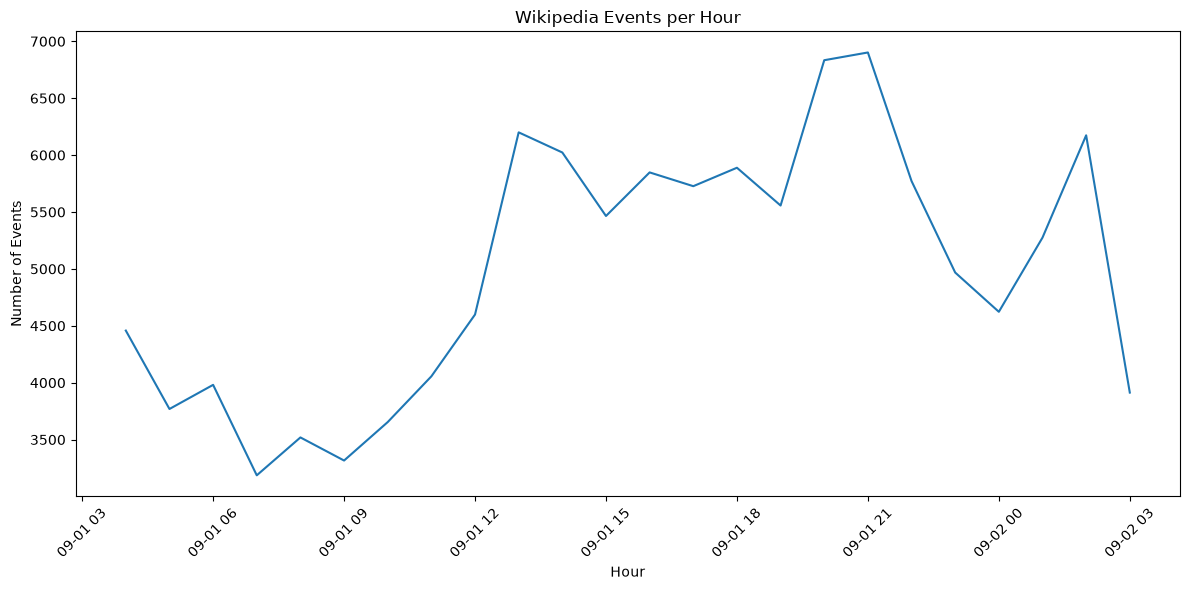

In [5]:
#making sure that datetime is stored as datetime value 
full_df["datetime"] = pd.to_datetime(full_df["datetime"])

#creating column for hour of each event 
full_df["hour"] = full_df["datetime"].dt.floor("h")

#counting total number of events in each hour
hourly_counts = (
    full_df.groupby("hour")
    .size()
    .reset_index(name="event_count")
)

#line plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_counts, 
    x="hour", 
    y="event_count"
)

#title + labels
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Wikipedia Events per Hour")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")

plt.show()

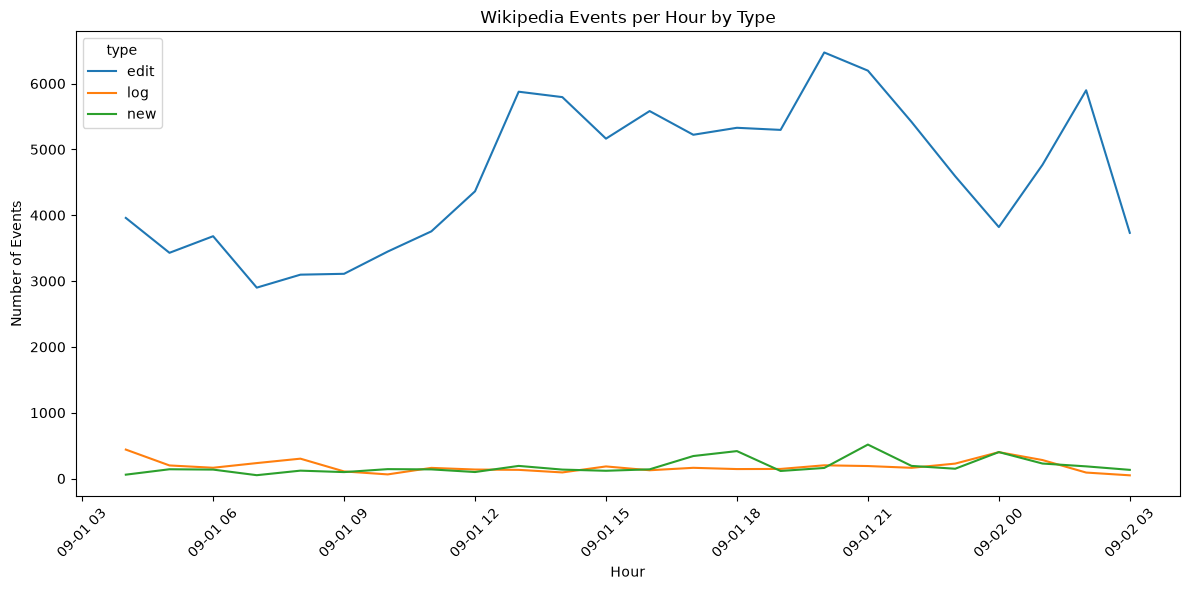

In [6]:
type_counts = (
    full_df.groupby(["hour", "type"])
    .size()
    .reset_index(name="event_count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=type_counts,
    x="hour",
    y="event_count",
    hue="type"
)

plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Wikipedia Events per Hour by Type")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")

plt.show()